<a href="https://colab.research.google.com/github/Nachos-mic/Lung_CT_Diagnostic_ML/blob/main/Lung_Diagnostics_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biblioteki


In [4]:
!pip install -q grad-cam

In [5]:
!pip install -q optuna

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import WeightedRandomSampler
import optuna
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import random
import torch.nn.functional as F


MERGED_STAGE_TO_LABEL = {
    'I': 0,
    'II': 1,
    'IIIa': 2,
    'IIIb': 2,
    'III': 2,
}
LABEL_TO_MERGED_STAGE = {
    0: 'I',
    1: 'II',
    2: 'III',
}
NUM_CLASSES = len(LABEL_TO_MERGED_STAGE)


def merge_stage_label(value):
    if pd.isna(value):
        raise ValueError('Missing stage or label value')

    if isinstance(value, str):
        normalized = value.strip()
        if normalized in MERGED_STAGE_TO_LABEL:
            return MERGED_STAGE_TO_LABEL[normalized]
        return 2 if normalized == 'III' else int(normalized)

    return 2 if int(value) == 3 else int(value)


Rozpakowanie danych do dysku (jednorazowe)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

#Tworzenie folderu z danymi
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/lung_dataset.zip" -d "/content/dataset"
print("Dane rozpakowane pomyślnie!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/dataset/data_2d_full_slices/LUNG1-001_slice_0060.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dane rozpakowane pomyślnie!


EDA dla datasetu - statystyki klas i wizualizacja przykładowych slice'ów

/tmp/ipykernel_31394/3281136734.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')


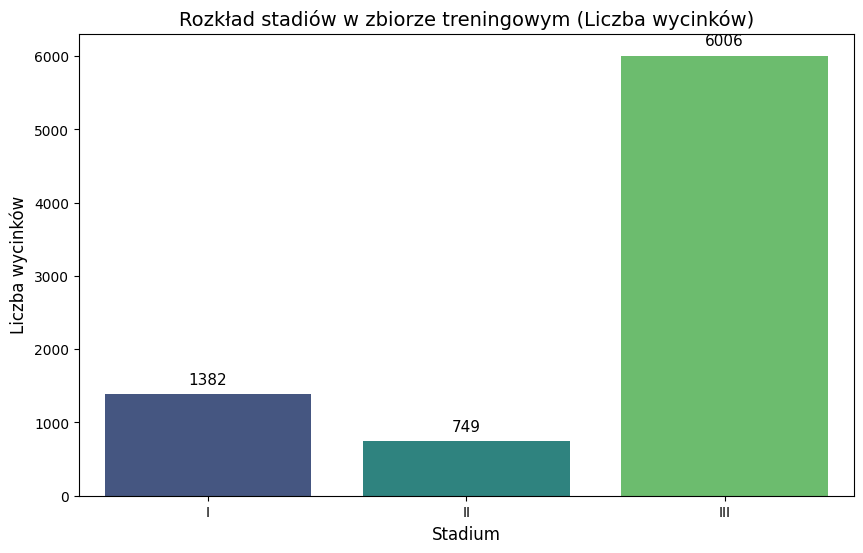


--- Przykładowe wycinki dla poszczególnych klas ---


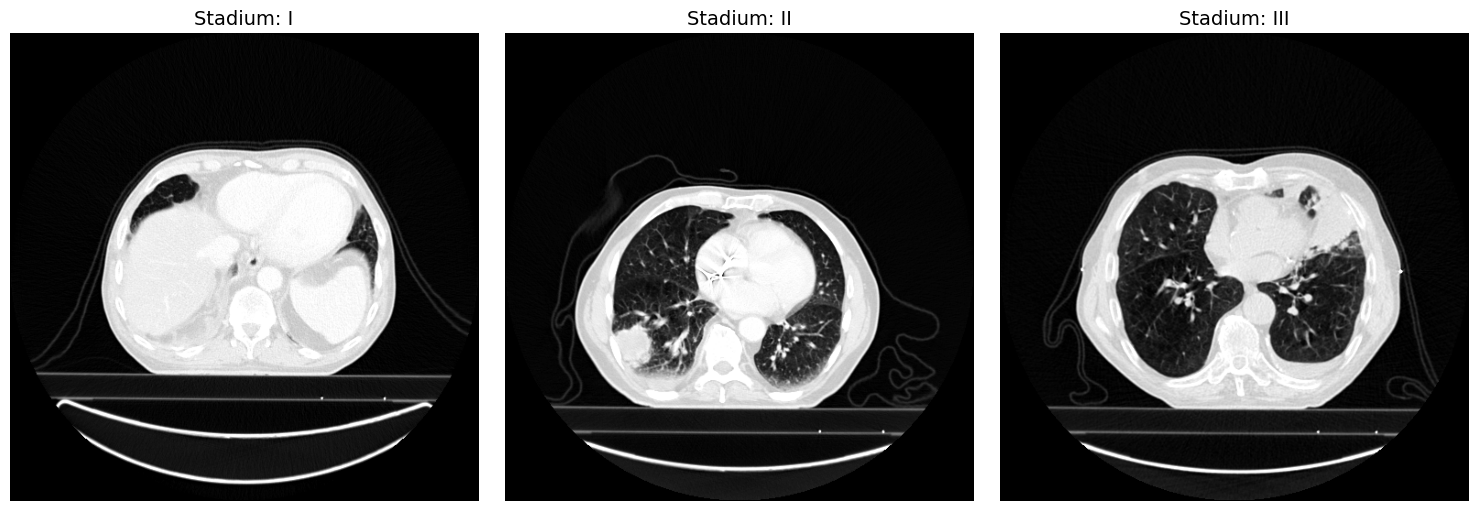

In [6]:
# Ścieżka do wypakowanego pliku train.csv
TRAIN_CSV = '/content/dataset/train.csv'

df_train = pd.read_csv(TRAIN_CSV)
df_train['merged_stage'] = df_train['original_stage'].replace({'IIIa': 'III', 'IIIb': 'III'})

# 1. Statystyki klas w zbiorze treningowym
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')
plt.title('Rozkład stadiów w zbiorze treningowym (Liczba wycinków)', fontsize=14)
plt.xlabel('Stadium', fontsize=12)
plt.ylabel('Liczba wycinków', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# 2. Wizualizacja przykładowych zdjęć dla każdej z 3 klas po połączeniu IIIa i IIIb
print("\n--- Przykładowe wycinki dla poszczególnych klas ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stages = ['I', 'II', 'III']

for i, stage in enumerate(stages):
    sample_img_path = df_train[df_train['merged_stage'] == stage].iloc[0]['image_path']

    clean_path = sample_img_path.replace('\\', '/')
    filename = os.path.basename(clean_path)

    colab_img_path = os.path.join('/content/dataset/data_2d_full_slices', filename)

    img = Image.open(colab_img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Stadium: {stage}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

EDA dla datasetu - demografia pacjentów, typy histologiczne i podział slice'ów pomiędzy pacjentami

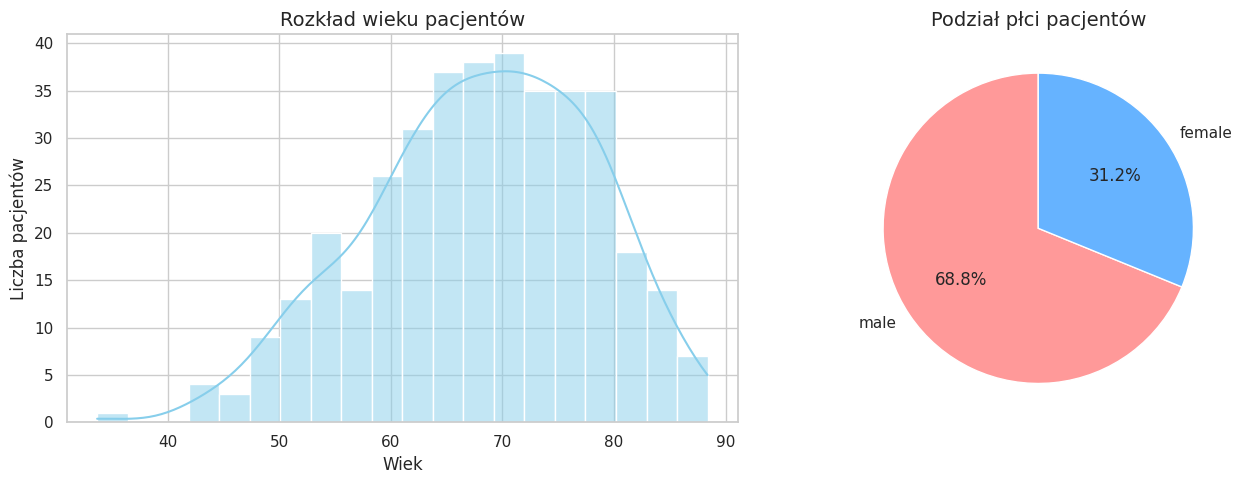

/tmp/ipykernel_31394/3080178802.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')


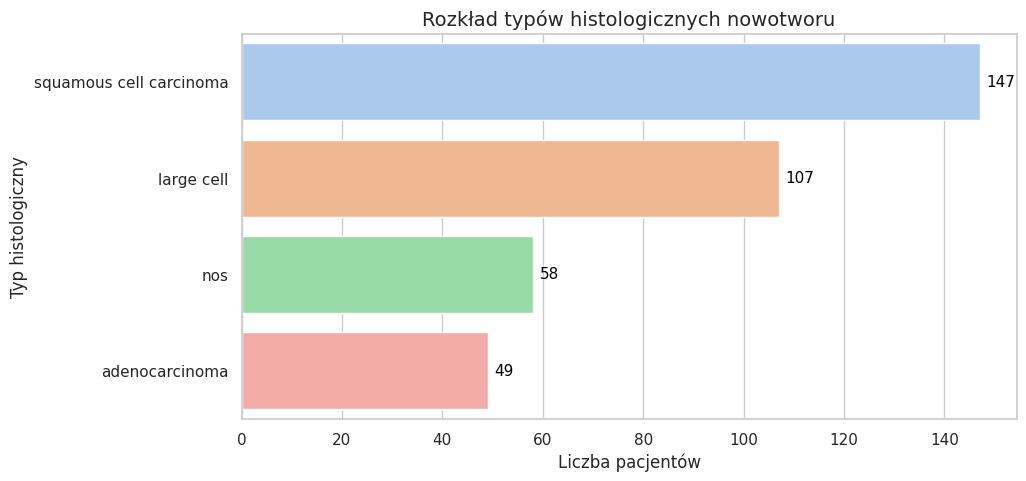

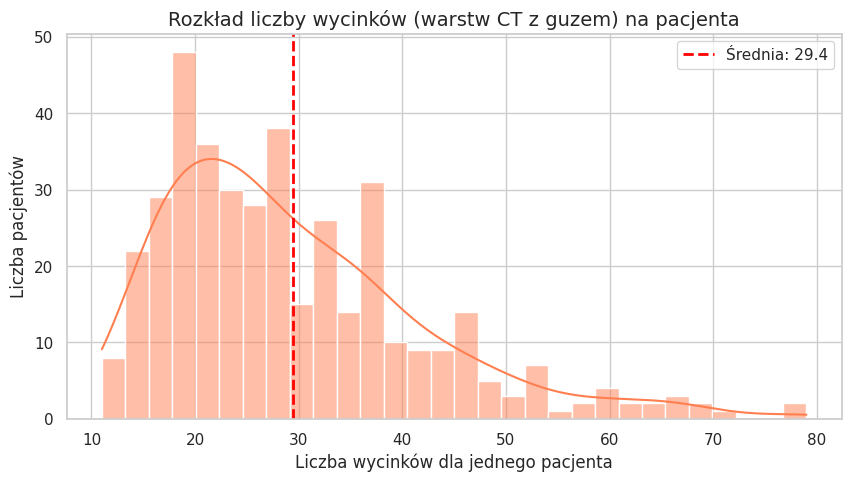

Całkowita liczba uwzględnionych pacjentów: 401
Średni wiek pacjenta: 68.1 lat (Min: 34, Max: 88)
Średnia liczba wycinków na pacjenta: 29.4
Pacjent z najmniejszą liczbą wycinków ma ich: 11
Pacjent z największą liczbą wycinków ma ich: 79


In [7]:

MASTER_CSV = r"/content/dataset/master_dataset.csv"
CLINICAL_CSV = r"/content/dataset/NSCLC-Radiomics-Lung1.clinical-data.csv"

df_master = pd.read_csv(MASTER_CSV)
df_clinical = pd.read_csv(CLINICAL_CSV)

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()
df_master['patient_id'] = df_master['patient_id'].astype(str).str.strip()

df_merged = df_master[['patient_id']].drop_duplicates().merge(
    df_clinical, left_on='patient_id', right_on='PatientID', how='inner'
)

sns.set_theme(style="whitegrid")

# WYKRES 1: Demografia (Wiek i Płeć)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(data=df_merged, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Rozkład wieku pacjentów', fontsize=14)
axes[0].set_xlabel('Wiek', fontsize=12)
axes[0].set_ylabel('Liczba pacjentów', fontsize=12)

gender_col = 'gender' if 'gender' in df_merged.columns else 'Gender' if 'Gender' in df_merged.columns else None

if gender_col:
    gender_counts = df_merged[gender_col].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Podział płci pacjentów', fontsize=14)

plt.tight_layout()
plt.show()

# WYKRES 2: Typy Histologiczne
histology_col = 'Histology' if 'Histology' in df_merged.columns else 'histology' if 'histology' in df_merged.columns else None

if histology_col:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')
    plt.title('Rozkład typów histologicznych nowotworu', fontsize=14)
    plt.xlabel('Liczba pacjentów', fontsize=12)
    plt.ylabel('Typ histologiczny', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')
    plt.show()

# WYKRES 3: Rozkład liczby warstw (wycinków) na pacjenta
plt.figure(figsize=(10, 5))
slices_per_patient = df_master.groupby('patient_id').size()

sns.histplot(slices_per_patient, bins=30, kde=True, color='coral')
plt.title('Rozkład liczby wycinków (warstw CT z guzem) na pacjenta', fontsize=14)
plt.xlabel('Liczba wycinków dla jednego pacjenta', fontsize=12)
plt.ylabel('Liczba pacjentów', fontsize=12)

mean_slices = slices_per_patient.mean()
plt.axvline(mean_slices, color='red', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_slices:.1f}')
plt.legend()
plt.show()

print(f"Całkowita liczba uwzględnionych pacjentów: {len(df_merged)}")
print(f"Średni wiek pacjenta: {df_merged['age'].mean():.1f} lat (Min: {df_merged['age'].min():.0f}, Max: {df_merged['age'].max():.0f})")
print(f"Średnia liczba wycinków na pacjenta: {mean_slices:.1f}")
print(f"Pacjent z najmniejszą liczbą wycinków ma ich: {slices_per_patient.min()}")
print(f"Pacjent z największą liczbą wycinków ma ich: {slices_per_patient.max()}")

Preprocessing do ResNet

In [8]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

# 1. Przekształcenia dla zbioru treningowego z augumentacją danych
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),

    transforms.ToTensor(),

    # Normalizacja standardowymi wartościami z ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Przekształcenia dla WALIDACJI i TESTU
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach o rozmiarze 224x224.")

Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach o rozmiarze 224x224.


Klasa Dataset

In [21]:
class LungCancerDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        csv_file: ścieżka do pliku np. train.csv
        root_dir: folder, w którym fizycznie leżą zdjęcia PNG
        transform: nasze reguły augmentacji z torchvision
        """
        self.data_frame = pd.read_csv(csv_file)
        if 'original_stage' in self.data_frame.columns:
            self.data_frame['merged_label'] = self.data_frame['original_stage'].apply(merge_stage_label)
        else:
            self.data_frame['merged_label'] = self.data_frame['label'].apply(merge_stage_label)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        raw_path = self.data_frame.iloc[idx]['image_path']
        clean_path = raw_path.replace('\\', '/')
        filename = os.path.basename(clean_path)

        img_path = os.path.join(self.root_dir, filename)

        #Wczyt obrazu, konwersja na RGB

        image = Image.open(img_path).convert('RGB')
        label = int(self.data_frame.iloc[idx]['merged_label'])

        if self.transform:
            image = self.transform(image)

        return image, label

# --- TWORZENIE DATALOADERÓW ---

IMG_DIR_COLAB = '/content/dataset/data_2d_full_slices'

train_dataset = LungCancerDataset(csv_file='/content/dataset/train.csv',
                                  root_dir=IMG_DIR_COLAB,
                                  transform=train_transforms)

val_dataset = LungCancerDataset(csv_file='/content/dataset/val.csv',
                                root_dir=IMG_DIR_COLAB,
                                transform=val_test_transforms)

test_dataset = LungCancerDataset(csv_file='/content/dataset/test.csv',
                                 root_dir=IMG_DIR_COLAB,
                                 transform=val_test_transforms)

#Weighted Sampler

train_labels = train_dataset.data_frame['merged_label'].values

num_classes = 3

class_counts = np.bincount(train_labels)
print("Class counts:", class_counts)

class_weights = 1. / class_counts

sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,sampler=sampler,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dane gotowe! Przykładowy batch treningowy ma rozmiar: {next(iter(train_loader))[0].shape}")

Class counts: [1382  749 6006]
Dane gotowe! Przykładowy batch treningowy ma rozmiar: torch.Size([32, 3, 224, 224])


FocalLoss

In [22]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

Trening ResNet- 18

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")
if device.type == 'cpu':
    print("UWAGA: Trenujesz na procesorze! Zmień środowisko wykonawcze w Colabie na T4 GPU (Środowisko wykonawcze -> Zmień typ środowiska).")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modyfikacja ostatniej warstwy (Klasyfikatora)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

model = model.to(device)


alpha = torch.FloatTensor([1.5, 2.5, 1.0]).to(device)
criterion = FocalLoss(alpha=alpha, gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("\nModel ResNet-50 gotowy do treningu!")

Używane urządzenie: cuda

Model ResNet-50 gotowy do treningu!


Pętla ucząca

In [ ]:
num_epochs = 20

# Zmienne do śledzenia obu rekordów
best_acc = 0.0
best_f1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

# Słownik śledzi teraz absolutnie wszystko
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': []
}

print("Rozpoczęcie treningu (Śledzenie Accuracy oraz F1-Score)\n")
start_time = time.time()

for epoch in range(num_epochs):
    print(f'Epoka {epoch+1}/{num_epochs}')
    print('-' * 20)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        # Listy na zbieranie predykcji do F1-score
        all_preds = []
        all_labels = []

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        # Obliczanie wszystkich trzech metryk (Loss, Acc, F1)
        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')

        print(f'{phase.upper()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1 (Macro): {epoch_f1:.4f}')

        # Zapisywanie do historii
        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
            history['train_f1'].append(epoch_f1)
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())
            history['val_f1'].append(epoch_f1)

            # Aktualizujemy rekord Accuracy (tylko informacyjnie)
            if epoch_acc > best_acc:
                best_acc = epoch_acc

            # Aktualizujemy rekord F1 i to na jego podstawie ZAPISUJEMY MODEL
            if epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), '/content/best_resnet18_model.pth')
                print(" >>> Zapisano nowy najlepszy model na dysku (wg F1-score)! <<< ")

    print()

time_elapsed = time.time() - start_time
print(f'Trening zakończony w {time_elapsed // 60:.0f} minut i {time_elapsed % 60:.0f} sekund.')
print(f'Najlepsza dokładność walidacyjna (Val Acc): {best_acc:.4f}')
print(f'Najlepszy F1-score walidacyjny (Val F1): {best_f1:.4f}')



model.load_state_dict(best_model_wts)
print("\nRaport Modelu")

model.eval()
final_preds = []
final_labels = []

# Ewaluacja na zbiorze walidacyjnym (możesz też potem zmienić na test_loader!)
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())

# Definiujemy etykiety do czytelnego raportu (dla 3 klas!)
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

# Raport klasyfikacji
print("\nRaport Klasyfikacji (Precision, Recall, F1 dla każdej klasy osobno):")
report = classification_report(final_labels, final_preds, target_names=target_names)
print(report)

# Rysowanie Macierzy Pomyłek
print("\nGenerowanie Macierzy Pomyłek (Confusion Matrix)...")
cm = confusion_matrix(final_labels, final_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Przewidywana Klasa (Predicted)')
plt.ylabel('Prawdziwa Klasa (True)')
plt.title('Macierz Pomyłek - Zbiór Walidacyjny (ResNet-18)')
plt.show()

Rozpoczęcie treningu (Śledzenie Accuracy oraz F1-Score)

Epoka 1/20
--------------------
TRAIN Loss: 0.0416 | Acc: 0.9698 | F1 (Macro): 0.9695
VAL Loss: 1.3817 | Acc: 0.7035 | F1 (Macro): 0.4453
 >>> Zapisano nowy najlepszy model na dysku (wg F1-score)! <<< 

Epoka 2/20
--------------------
TRAIN Loss: 0.0309 | Acc: 0.9776 | F1 (Macro): 0.9775
VAL Loss: 1.4878 | Acc: 0.7138 | F1 (Macro): 0.4975
 >>> Zapisano nowy najlepszy model na dysku (wg F1-score)! <<< 

Epoka 3/20
--------------------
TRAIN Loss: 0.0207 | Acc: 0.9830 | F1 (Macro): 0.9830
VAL Loss: 1.4927 | Acc: 0.7107 | F1 (Macro): 0.5109
 >>> Zapisano nowy najlepszy model na dysku (wg F1-score)! <<< 

Epoka 4/20
--------------------
TRAIN Loss: 0.0283 | Acc: 0.9801 | F1 (Macro): 0.9801
VAL Loss: 1.6190 | Acc: 0.6419 | F1 (Macro): 0.4261

Epoka 5/20
--------------------
TRAIN Loss: 0.0375 | Acc: 0.9727 | F1 (Macro): 0.9725
VAL Loss: 1.6877 | Acc: 0.7065 | F1 (Macro): 0.4650

Epoka 6/20
--------------------
TRAIN Loss: 0.0260 | Acc

# Historia

22.03.2026

Ilość epok: 10
Wartość treningowa: 0.9762
Wartość walidacyjna: 0.5550

Werdykt - Overfitting

--------------------------------------------------------------------------------

03.04.2026

Ilość epok: 25
Wartość treningowa: 0.
Wartość walidacyjna: 0.6021
F1: 0.4628

Werdykt: Overfitting

--------------------------------------------------------------------------------

Użyto weightedsamplera oraz klasę 3a i 3b połączono w jedną
10.04.2026

Epoki:10
Najlepsza dokładność walidacyjna (Val Acc): 0.7729
Najlepszy F1-score walidacyjny (Val F1): 0.5223

Werdykt - delikatny overfitting, z niezbalansowaniem klas

Krzywa uczenia i straty

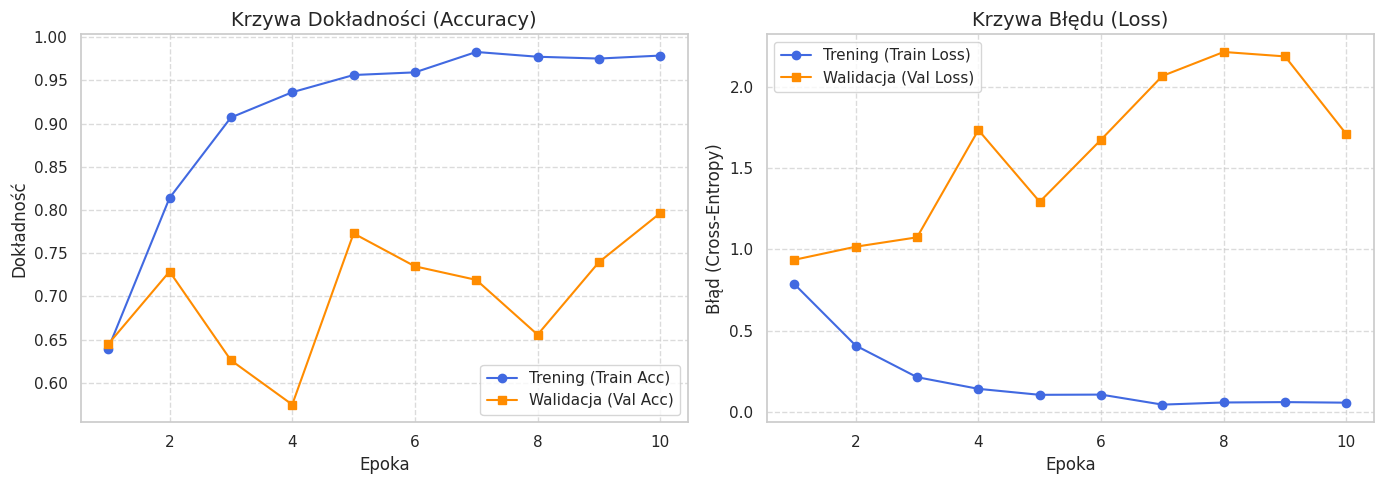

In [12]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# --- Wykres 1: Dokładność (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Trening (Train Acc)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_acc'], label='Walidacja (Val Acc)', marker='s', color='darkorange')
plt.title('Krzywa Dokładności (Accuracy)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Dokładność', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- Wykres 2: Funkcja błędu (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Trening (Train Loss)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_loss'], label='Walidacja (Val Loss)', marker='s', color='darkorange')
plt.title('Krzywa Błędu (Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Błąd (Cross-Entropy)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('/content/learning_curves_resnet18.png', dpi=300)
plt.show()

Grad-Cam

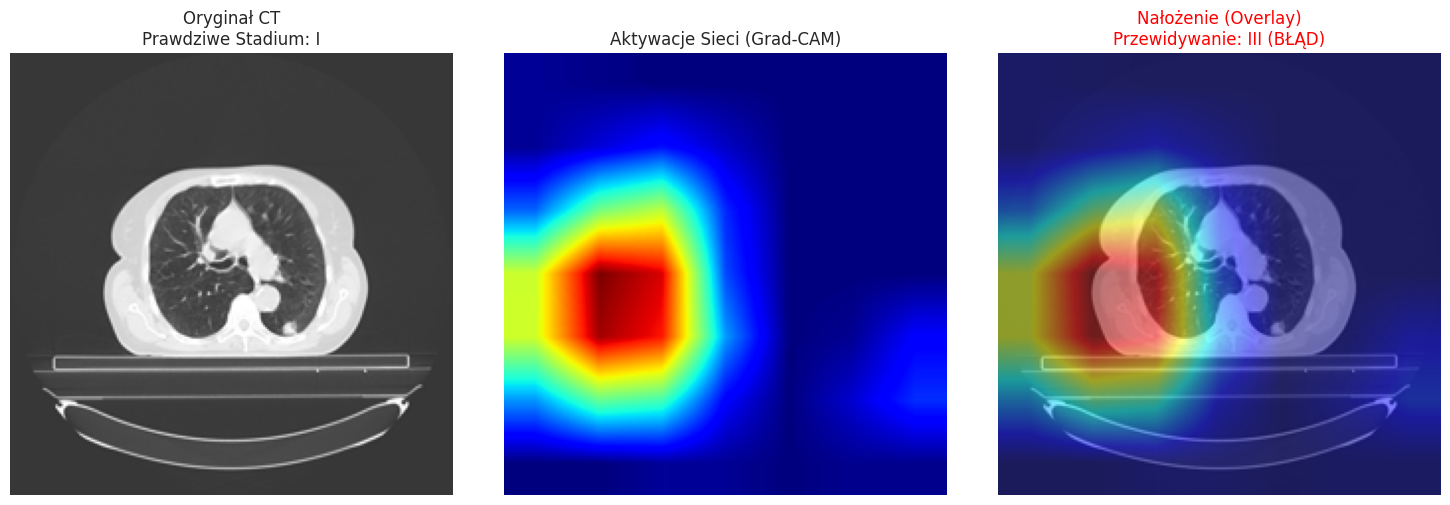

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Wczytanie wytrenowanego modelu
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/best_resnet18_model.pth'))
model = model.to(device)
model.eval()

target_layers = [model.layer4[-1]]

# Losowanie obrazu testowego
df_test = pd.read_csv('/content/dataset/test.csv')
sample_row = df_test.iloc[random.randint(0, len(df_test) - 1)]

img_path = sample_row['image_path'].replace('\\', '/')
full_img_path = os.path.join('/content/dataset/data_2d_full_slices', os.path.basename(img_path))

actual_label = merge_stage_label(sample_row['original_stage']) if 'original_stage' in sample_row.index else merge_stage_label(sample_row['label'])
actual_stage = LABEL_TO_MERGED_STAGE[actual_label]
stage_dict = LABEL_TO_MERGED_STAGE

# Preprocessing
rgb_img_pil = Image.open(full_img_path).convert('RGB').resize((224, 224))
rgb_img_float = np.float32(rgb_img_pil) / 255.0

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(rgb_img_pil).unsqueeze(0).to(device)

# Predykcja
with torch.no_grad():
    output = model(input_tensor)
    predicted_label = torch.argmax(output, dim=1).item()
    predicted_stage = stage_dict[predicted_label]

# Generowanie mapy ciepła Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(predicted_label)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

# Wyświetlanie wyników
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_img_pil, cmap='gray')
plt.title(f'Oryginał CT\nPrawdziwe Stadium: {actual_stage}', fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title('Aktywacje Sieci (Grad-CAM)', fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(visualization)

color = 'green' if actual_label == predicted_label else 'red'
wynik = "SUKCES" if actual_label == predicted_label else "BŁĄD"

plt.title(f'Nałożenie (Overlay)\nPrzewidywanie: {predicted_stage} ({wynik})', fontsize=12, color=color)
plt.axis('off')

plt.tight_layout()
plt.show()

# Optuna


Tutaj celujemy w usprawnienie f1-score

In [18]:
EPOCHS_PER_TRIAL = 10
NUM_CLASSES = 3

def objective(trial):
    # Hiperparametry początkowe
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.6)
    hidden_units = trial.suggest_categorical("hidden_units", [128, 256, 512])

    # Inicjalizacja ResNet-18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(num_features, hidden_units),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate),
        nn.Linear(hidden_units, NUM_CLASSES)
    )
    model = model.to(device)

    # Funkcja błędu i Optymalizator
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Pętla treningowa
    for epoch in range(EPOCHS_PER_TRIAL):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)

                probs = F.softmax(outputs, dim=1)
                all_probs.extend(probs.cpu().numpy())

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())


        val_f1 = f1_score(all_labels, all_preds, average='macro')

        try:
            val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except ValueError:
            val_auc = 0.0

        # Optuna używa val_f1 do podejmowania decyzji o kierunku optymalizacji
        trial.report(val_f1, epoch)

        # Pruning (odcinanie beznadziejnych prób)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_f1

# 6. Start badania
study = optuna.create_study(direction="maximize", study_name="ResNet18_3Classes_Opt")
study.optimize(objective, n_trials=15)

print("\n✅ Koniec Optymalizacji!")
print("Najlepsze F1-Score:", study.best_value)
print("Najlepsze parametry:", study.best_trial.params)

[I 2026-04-10 14:12:56,364] A new study created in memory with name: ResNet18_3Classes_Opt
[I 2026-04-10 14:24:59,931] Trial 0 finished with value: 0.46292347254483096 and parameters: {'lr': 4.9537596207382824e-05, 'weight_decay': 0.00908395034122119, 'dropout_rate': 0.1985822292987963, 'hidden_units': 512}. Best is trial 0 with value: 0.46292347254483096.
[I 2026-04-10 14:37:10,353] Trial 1 finished with value: 0.3965075479396165 and parameters: {'lr': 0.00044718251374859224, 'weight_decay': 0.006232675776925648, 'dropout_rate': 0.4330599365037673, 'hidden_units': 128}. Best is trial 0 with value: 0.46292347254483096.
[I 2026-04-10 14:48:59,907] Trial 2 finished with value: 0.4267858051130644 and parameters: {'lr': 0.0009568875378864905, 'weight_decay': 0.004613077756288834, 'dropout_rate': 0.10464355071517781, 'hidden_units': 256}. Best is trial 0 with value: 0.46292347254483096.
[I 2026-04-10 15:00:34,370] Trial 3 finished with value: 0.4723896248286492 and parameters: {'lr': 4.1246

KeyboardInterrupt: 

In [ ]:
best_params = study.best_trial.params
print("Using best parameters from Optuna:")
print(best_params)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, best_params['hidden_units']),
    nn.ReLU(),
    nn.Dropout(p=best_params['dropout_rate']),
    nn.Linear(best_params['hidden_units'], NUM_CLASSES)
)
model = model.to(device)

class_counts = train_dataset.data_frame['merged_label'].value_counts().sort_index().tolist()
total_samples = sum(class_counts)
num_classes = NUM_CLASSES
class_weights = [total_samples / (num_classes * count) for count in class_counts]
weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.1, patience=5, verbose=True, min_lr=1e-6
)

NUM_EPOCHS = 50
PATIENCE = 15

best_val_f1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0

history_optimized = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'overfitting_gap': []
}

print("\nTraining with optimized hyperparameters and overfitting prevention\n")

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 40)

    model.train()
    running_loss = 0.0
    running_corrects = 0
    all_train_preds = []
    all_train_labels = []

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = running_corrects.double() / len(train_loader.dataset)
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = val_corrects.double() / len(val_loader.dataset)
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    overfitting_gap = train_acc.item() - val_acc.item()

    print(f'TRAIN | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
    print(f'VAL   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')
    print(f'Overfitting Gap: {overfitting_gap:.4f}')

    history_optimized['train_loss'].append(train_loss)
    history_optimized['val_loss'].append(val_loss)
    history_optimized['train_acc'].append(train_acc.item())
    history_optimized['val_acc'].append(val_acc.item())
    history_optimized['train_f1'].append(train_f1)
    history_optimized['val_f1'].append(val_f1)
    history_optimized['overfitting_gap'].append(overfitting_gap)

    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), '/content/best_resnet18_optimized.pth')
        patience_counter = 0
        print("✓ New best model saved!")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping! No improvement for {PATIENCE} epochs.")
        break

    print()

time_elapsed = time.time() - start_time
print(f'Training completed in {time_elapsed // 60:.0f} min and {time_elapsed % 60:.0f} sec.')
print(f'Best validation F1-score: {best_val_f1:.4f}')

model.load_state_dict(best_model_wts)

In [ ]:
epochs_range = range(1, len(history_optimized['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(epochs_range, history_optimized['train_acc'], label='Training', marker='o', color='royalblue', linewidth=2)
axes[0, 0].plot(epochs_range, history_optimized['val_acc'], label='Validation', marker='s', color='darkorange', linewidth=2)
axes[0, 0].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, history_optimized['train_f1'], label='Training', marker='o', color='green', linewidth=2)
axes[0, 1].plot(epochs_range, history_optimized['val_f1'], label='Validation', marker='s', color='red', linewidth=2)
axes[0, 1].set_title('F1-Score (Macro)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, history_optimized['train_loss'], label='Training', marker='o', color='royalblue', linewidth=2)
axes[1, 0].plot(epochs_range, history_optimized['val_loss'], label='Validation', marker='s', color='darkorange', linewidth=2)
axes[1, 0].set_title('Loss', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_range, history_optimized['overfitting_gap'], color='purple', marker='o', linewidth=2)
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, label='No Overfitting')
axes[1, 1].fill_between(epochs_range, 0, history_optimized['overfitting_gap'], alpha=0.3, color='purple')
axes[1, 1].set_title('Overfitting Gap (Train Acc - Val Acc)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Difference')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_optimization_results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average overfitting gap: {np.mean(history_optimized['overfitting_gap']):.4f}")
print(f"Maximum overfitting gap: {np.max(history_optimized['overfitting_gap']):.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
test_corrects = 0
all_test_preds = []
all_test_labels = []
test_loss = 0.0

print("Evaluating on test set...\n")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        test_corrects += torch.sum(preds == labels.data)
        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

test_acc = test_corrects.double() / len(test_loader.dataset)
test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')
test_loss = test_loss / len(test_loader.dataset)

print("="*60)
print("TEST SET RESULTS:")
print("="*60)
print(f"Accuracy:  {test_acc:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"Loss:      {test_loss:.4f}")
print("="*60)

cm = confusion_matrix(all_test_labels, all_test_preds)
stage_names = ['Stage I', 'Stage II', 'Stage III']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=stage_names, yticklabels=stage_names, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=stage_names, digits=4))

print("\n" + "="*60)
print("OPTIMIZATION SUMMARY:")
print("="*60)
print(f"Previous F1 (25 epochs):   0.4628")
print(f"New F1 (Optuna):           {best_val_f1:.4f}")
print(f"Improvement:               {(best_val_f1 - 0.4628)*100:.2f}%")
print("="*60)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_grad = models.resnet50(weights=None)
num_features_grad = model_grad.fc.in_features
model_grad.fc = nn.Sequential(
    nn.Linear(num_features_grad, best_params['hidden_units']),
    nn.ReLU(),
    nn.Dropout(p=best_params['dropout_rate']),
    nn.Linear(best_params['hidden_units'], NUM_CLASSES)
)
model_grad.load_state_dict(torch.load('/content/best_resnet18_optimized.pth'))
model_grad = model_grad.to(device)
model_grad.eval()

target_layers_grad = [model_grad.layer4[-1]]

df_test = pd.read_csv('/content/dataset/test.csv')
stage_dict = LABEL_TO_MERGED_STAGE

print("Grad-CAM Visualization for Optimized Model\n")
print("="*60)

for i in range(5):
    sample_row = df_test.iloc[np.random.randint(0, len(df_test))]

    img_path = sample_row['image_path'].replace('\\', '/')
    full_img_path = os.path.join('/content/dataset/data_2d_full_slices', os.path.basename(img_path))

    actual_label = merge_stage_label(sample_row['original_stage']) if 'original_stage' in sample_row.index else merge_stage_label(sample_row['label'])
    actual_stage = stage_dict[actual_label]

    rgb_img_pil = Image.open(full_img_path).convert('RGB').resize((224, 224))
    rgb_img_float = np.float32(rgb_img_pil) / 255.0

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(rgb_img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model_grad(input_tensor)
        predicted_label = torch.argmax(output, dim=1).item()
        predicted_stage = stage_dict[predicted_label]
        confidence = torch.softmax(output, dim=1)[0, predicted_label].item()

    cam = GradCAM(model=model_grad, target_layers=target_layers_grad)
    targets = [ClassifierOutputTarget(predicted_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img_pil, cmap='gray')
    plt.title(f'Original CT\nTrue Stage: {actual_stage}', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(grayscale_cam, cmap='jet')
    plt.title('Network Activations (Grad-CAM)', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(visualization)

    color = 'green' if actual_label == predicted_label else 'red'
    result = "CORRECT" if actual_label == predicted_label else "INCORRECT"

    plt.title(f'Overlay\nPredicted: {predicted_stage}\nConfidence: {confidence:.2%} ({result})',
              fontsize=12, color=color)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Sample {i+1}: True={actual_stage} | Predicted={predicted_stage} | Confidence={confidence:.2%}")

print("="*60)